# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

In this project, I worked on a Zomato restaurant reviews dataset to understand customer opinions, restaurant performance, and factors that influence customer satisfaction. The project uses two different datasets. The first dataset contains 10,000 customer reviews, including information such as reviewer names, ratings, review text, review time, and pictures uploaded by customers. The second dataset contains restaurant-related information for 105 restaurants, including restaurant names, cuisines, cost, collections, timings, and restaurant links.

The project started with understanding the structure of both datasets and examining their quality. I checked the number of rows and columns, data types, duplicate records, and missing values. During this process, I found duplicate entries in the reviews dataset and missing values in multiple columns such as Reviewer, Review, Rating, Metadata, Time, Collections, and Timings. These issues were handled during the data cleaning stage to ensure that the dataset was reliable and suitable for further analysis.

After cleaning the data, the reviews dataset and restaurant metadata dataset were merged into a single dataset using restaurant names. This created a comprehensive dataset containing both customer feedback and restaurant details. I then performed exploratory data analysis to understand important patterns and trends in the data. Multiple visualizations were created to study restaurant costs, customer ratings, cuisine popularity, review lengths, customer engagement, and relationships between important variables. These visualizations helped identify meaningful insights about customer preferences and restaurant performance.

Since customer reviews are textual in nature, I also performed sentiment analysis. Several text preprocessing techniques were applied before analysis, including contraction expansion, lowercasing, punctuation removal, URL removal, stopword removal, tokenization, lemmatization, and part-of-speech tagging. These steps helped clean and standardize the review text. TF-IDF vectorization was then used to convert textual reviews into numerical features that could be used for analysis and machine learning.

To validate important observations from the exploratory analysis, hypothesis testing was performed using appropriate statistical methods. Relationships between variables such as restaurant cost, customer ratings, sentiment, and customer engagement were examined. These tests helped determine whether the observed relationships were statistically significant and supported by data.

In the machine learning section, K-Means clustering was used to group restaurants based on important features such as cost, ratings, review length, and customer engagement. Different cluster values were tested and compared using the Silhouette Score. Hyperparameter tuning was performed by evaluating multiple cluster configurations and selecting the model that provided better cluster separation and more meaningful segmentation.

Overall, this project helped me gain practical experience in data cleaning, exploratory data analysis, data visualization, natural language processing, hypothesis testing, feature engineering, and machine learning. The insights generated from this analysis can help restaurant owners understand customer preferences, improve service quality, optimize pricing strategies, and make better business decisions. The project demonstrates how data-driven approaches can be used to extract valuable insights from customer reviews and restaurant information.

# **GitHub Link -**

https://github.com/arpanharnal01/Zomato-Restaurant-Analysis.git

# **Problem Statement**


Online food platforms like Zomato receive thousands of customer reviews every day. These reviews contain valuable information about customer experiences, restaurant quality, pricing, and overall satisfaction. However, due to the large volume of data, it becomes difficult to manually analyze customer feedback and identify useful insights.

The main goal of this project is to analyze restaurant reviews and restaurant-related information to better understand customer preferences and restaurant performance. By performing data analysis, sentiment analysis, and machine learning, the project aims to discover important patterns, relationships, and trends hidden within the data.

The insights generated from this project can help restaurant owners improve their services, understand customer expectations, make better business decisions, and enhance the overall customer experience.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

### Dataset Loading

In [64]:
!pip install wordcloud textblob scikit-learn seaborn matplotlib pandas numpy


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from textblob import TextBlob

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [66]:
reviews = pd.read_csv("Zomato Restaurant reviews.csv")
meta = pd.read_csv("Zomato Restaurant names and Metadata.csv")

print(reviews.columns)
print("\n")
print(meta.columns)

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='str')


Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='str')


### Dataset First View

In [67]:
print("REVIEWS DATASET")
display(reviews.head())

print("\n")

print("METADATA DATASET")
display(meta.head())

REVIEWS DATASET


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0




METADATA DATASET


,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


### Dataset Rows & Columns count

In [68]:
print("Reviews Dataset Shape:", reviews.shape)
print("Metadata Dataset Shape:", meta.shape)

print("\nReviews Dataset Rows:", reviews.shape[0])
print("Reviews Dataset Columns:", reviews.shape[1])

print("\nMetadata Dataset Rows:", meta.shape[0])
print("Metadata Dataset Columns:", meta.shape[1])

Reviews Dataset Shape: (10000, 7)
Metadata Dataset Shape: (105, 6)

Reviews Dataset Rows: 10000
Reviews Dataset Columns: 7

Metadata Dataset Rows: 105
Metadata Dataset Columns: 6


### Dataset Information

In [69]:
print("REVIEWS DATASET INFORMATION")
reviews.info()

print("\n" + "="*50 + "\n")

print("METADATA DATASET INFORMATION")
meta.info()

REVIEWS DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Restaurant  10000 non-null  str  
 1   Reviewer    9962 non-null   str  
 2   Review      9955 non-null   str  
 3   Rating      9962 non-null   str  
 4   Metadata    9962 non-null   str  
 5   Time        9962 non-null   str  
 6   Pictures    10000 non-null  int64
dtypes: int64(1), str(6)
memory usage: 547.0 KB


METADATA DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         105 non-null    str  
 1   Links        105 non-null    str  
 2   Cost         105 non-null    str  
 3   Collections  51 non-null     str  
 4   Cuisines     105 non-null    str  
 5   Timings      104 non-null    str  
dtypes: str(6)
memory usage: 5.1 

#### Duplicate Values

In [70]:
print("Duplicate Rows in Reviews Dataset:")
print(reviews.duplicated().sum())

print("\nDuplicate Rows in Metadata Dataset:")
print(meta.duplicated().sum())

Duplicate Rows in Reviews Dataset:
36

Duplicate Rows in Metadata Dataset:
0


#### Missing Values/Null Values

In [71]:
print("Missing Values in Reviews Dataset")
print(reviews.isnull().sum())

print("\n" + "="*50 + "\n")

print("Missing Values in Metadata Dataset")
print(meta.isnull().sum())

Missing Values in Reviews Dataset
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


Missing Values in Metadata Dataset
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64


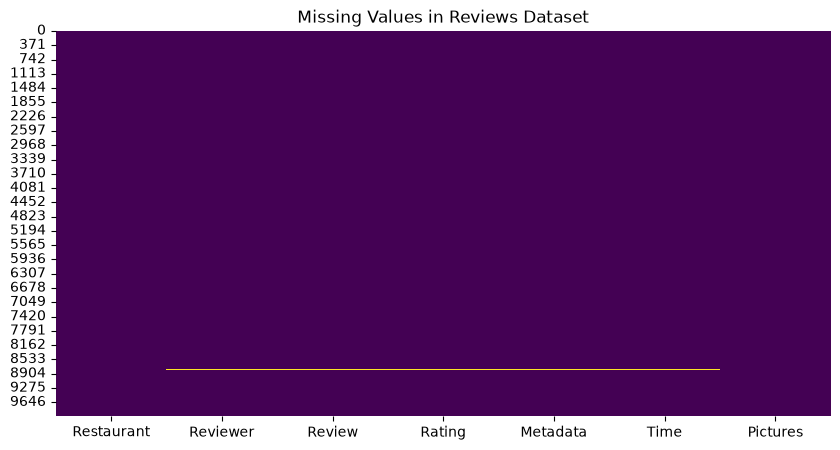

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(reviews.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values in Reviews Dataset")
plt.show()

### What did you know about your dataset?

This project uses two datasets related to Zomato restaurants. The first dataset contains 10,000 customer reviews along with information such as reviewer names, ratings, review text, review time, and pictures. The second dataset contains details of 105 restaurants, including their cost, cuisines, collections, timings, and restaurant links.

During the initial exploration of the data, I examined the structure, size, and quality of both datasets. The reviews dataset was found to contain 36 duplicate records, whereas no duplicate entries were present in the restaurant metadata dataset. A few missing values were also identified in columns such as Reviewer, Review, Rating, Metadata, Time, Collections, and Timings.

Overall, the datasets provide valuable information about customer experiences and restaurant characteristics. Before moving on to exploratory data analysis, sentiment analysis, and clustering, the data will be cleaned and preprocessed to ensure accurate and reliable results.


## ***2. Understanding Your Variables***

In [73]:
print("Reviews Dataset Columns:")
print(reviews.columns)

print("\n")

print("Metadata Dataset Columns:")
print(meta.columns)

Reviews Dataset Columns:
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='str')


Metadata Dataset Columns:
Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='str')


In [74]:
print("Reviews Dataset Summary")
display(reviews.describe(include='all'))

print("\n")

print("Metadata Dataset Summary")
display(meta.describe(include='all'))

Reviews Dataset Summary


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
count,10000,9962,9955,9962,9962,9962,10000.000000
unique,100,7446,9364,10,2477,9782,NaN
top,Beyond Flavours,Ankita,good,5,1 Review,5/5/2019 22:39,NaN
freq,100,13,237,3832,919,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.748600
std,NaN,NaN,NaN,NaN,NaN,NaN,2.570381
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000




Metadata Dataset Summary


,Name,Links,Cost,Collections,Cuisines,Timings
count,105,105,105,51,105,104
unique,105,105,29,42,92,77
top,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,500,Food Hygiene Rated Restaurants in Hyderabad,"North Indian, Chinese",11 AM to 11 PM
freq,1,1,13,4,4,6


### Variables Description

The reviews dataset provides details about customer experiences and opinions of different restaurants. The **Restaurant** column shows the name of the restaurant being reviewed, while **Reviewer** contains the name of the customer who wrote the review. The **Review** column includes the actual feedback shared by customers, and **Rating** reflects their overall satisfaction with the restaurant. Additional information related to the review is available in the **Metadata** column, **Time** records when the review was posted, and **Pictures** indicates the number of photos uploaded along with the review.

The metadata dataset focuses on restaurant-specific information. The **Name** column contains the restaurant name, and **Links** provides the corresponding restaurant webpage or URL. The **Cost** column gives an estimate of the average expense for two people. **Collections** highlights restaurant categories or special tags, **Cuisines** lists the types of food offered, and **Timings** provides information about the restaurant’s operating hours.


### Check Unique Values for each variable.

In [75]:
print("Unique Restaurants in Reviews Dataset:", reviews['Restaurant'].nunique())
print("Unique Reviewers:", reviews['Reviewer'].nunique())

print("\nUnique Restaurant Names in Metadata Dataset:", meta['Name'].nunique())
print("Unique Cuisines:", meta['Cuisines'].nunique())
print("Unique Collections:", meta['Collections'].nunique())

Unique Restaurants in Reviews Dataset: 100
Unique Reviewers: 7446

Unique Restaurant Names in Metadata Dataset: 105
Unique Cuisines: 92
Unique Collections: 42


## 3. ***Data Wrangling***

### Data Wrangling Code

In [76]:
# Remove duplicate rows
reviews = reviews.drop_duplicates()

# Handle missing values
reviews = reviews.dropna(subset=['Restaurant'])

reviews['Reviewer'] = reviews['Reviewer'].fillna('Unknown')
reviews['Review'] = reviews['Review'].fillna('No Review')
reviews['Rating'] = reviews['Rating'].fillna(reviews['Rating'].mode()[0])
reviews['Metadata'] = reviews['Metadata'].fillna('Not Available')
reviews['Time'] = reviews['Time'].fillna('Not Available')

meta['Collections'] = meta['Collections'].fillna('Not Specified')
meta['Timings'] = meta['Timings'].fillna('Not Available')

# Create a common column name for merging
meta.rename(columns={'Name':'Restaurant'}, inplace=True)

# Convert Rating column into numeric
reviews['Rating'] = reviews['Rating'].replace('Like', 5)
reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Rating'].fillna(reviews['Rating'].median(), inplace=True)

# Convert Cost column into numeric
meta['Cost'] = meta['Cost'].astype(str).str.replace(',', '')
meta['Cost'] = pd.to_numeric(meta['Cost'], errors='coerce')
meta['Cost'].fillna(meta['Cost'].median(), inplace=True)

# Merge datasets
df = pd.merge(reviews, meta, on='Restaurant', how='left')

print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (9964, 12)


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,"1 Review , 2 Followers",5/25/2019 15:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,"3 Reviews , 2 Followers",5/25/2019 14:20,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,"2 Reviews , 3 Followers",5/24/2019 22:54,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,"1 Review , 1 Follower",5/24/2019 22:11,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,"3 Reviews , 2 Followers",5/24/2019 21:37,0,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


### What all manipulations have you done and insights you found?

To prepare the data for analysis, duplicate rows were removed from the reviews dataset. Missing values were handled by filling empty text fields with simple labels and replacing missing ratings with the most common rating.

The reviews dataset and restaurant metadata dataset were then combined using the restaurant name. This created one dataset containing both restaurant details and customer reviews.

After cleaning and merging, the dataset became easier to analyze. It includes useful information such as restaurant names, cuisines, cost, ratings, and customer reviews, which can be used for further analysis and visualization.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

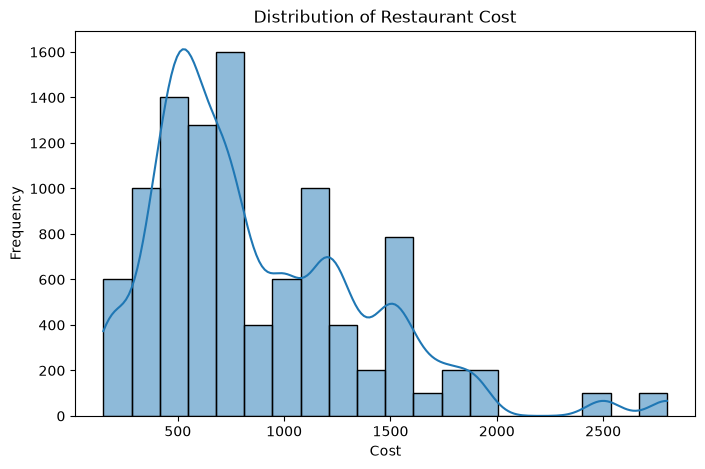

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(df['Cost'], bins=20, kde=True)

plt.title("Distribution of Restaurant Cost")
plt.xlabel("Cost")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram because it helps show how restaurant costs are spread across the dataset. It makes it easy to see the most common price ranges, check if the data is skewed, and understand which cost segment has the highest number of restaurants.


##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of restaurant costs and helps identify the most common spending range among customers. Most restaurants appear to be concentrated within a specific cost range, while only a small number of restaurants fall into very high-cost categories. This indicates that the platform primarily caters to customers looking for affordable to moderately priced dining options.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses understand how much customers usually spend. Restaurants can set better prices based on customer preferences, and Zomato can recommend restaurants that match different budget ranges.


#### Chart - 2

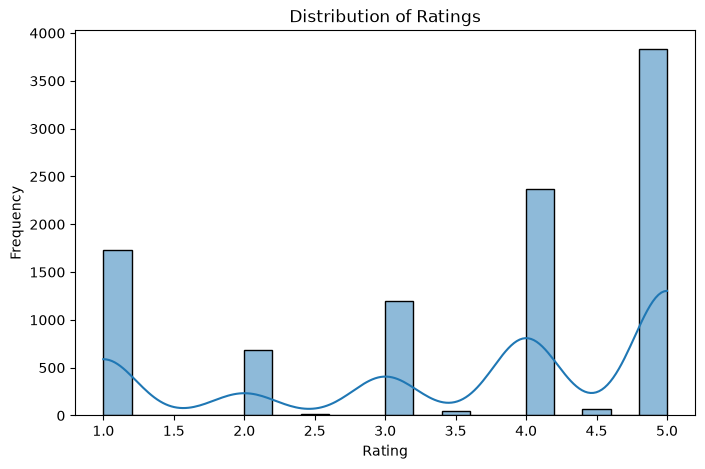

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rating'], bins=20, kde=True)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram because it helps visualize how customer ratings are distributed across restaurants. It allows us to identify the most common rating range and understand overall customer satisfaction levels.


##### 2. What is/are the insight(s) found from the chart?

The chart shows how ratings are distributed among restaurants. Most ratings are concentrated in the higher range, indicating that customers generally have positive experiences with the restaurants listed on the platform.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, rating patterns help restaurants understand how satisfied customers are. Restaurants with low ratings can improve their service, while restaurants with high ratings can attract more customers and get better promotion on the platform.

Restaurants receiving consistently low ratings may experience reduced customer trust and fewer orders. Identifying such patterns early can help restaurant owners take corrective actions and improve customer experience.


#### Chart - 3

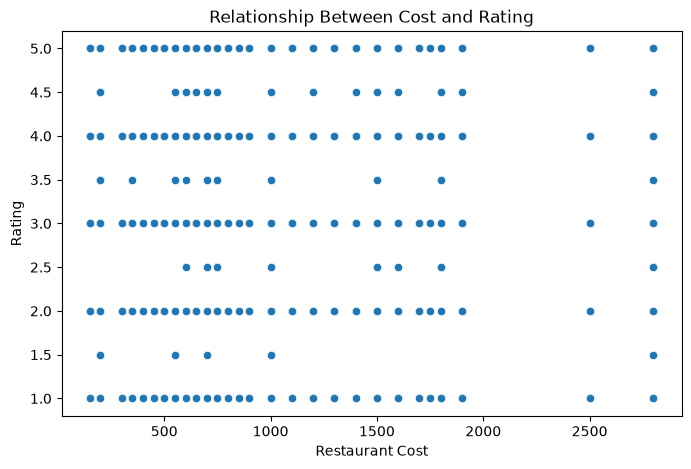

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Cost', y='Rating')

plt.title("Relationship Between Cost and Rating")
plt.xlabel("Restaurant Cost")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

I chose a scatter plot because I wanted to check if there is any relationship between the cost of a restaurant and the rating given by customers. It helps in comparing two variables at the same time and makes trends easier to identify.

##### 2. What is/are the insight(s) found from the chart?

From the chart, I observed that restaurants with higher costs do not always receive higher ratings. Both low-cost and high-cost restaurants have a mix of ratings, which shows that customer satisfaction depends on factors other than just pricing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can help restaurant owners understand that increasing prices alone may not improve customer satisfaction. Focusing on food quality, service, and customer experience can be more effective in maintaining good ratings.
Some expensive restaurants have average or low ratings. If customers feel that the quality does not justify the price, they may choose competing restaurants, which can affect business growth.

#### Chart - 4

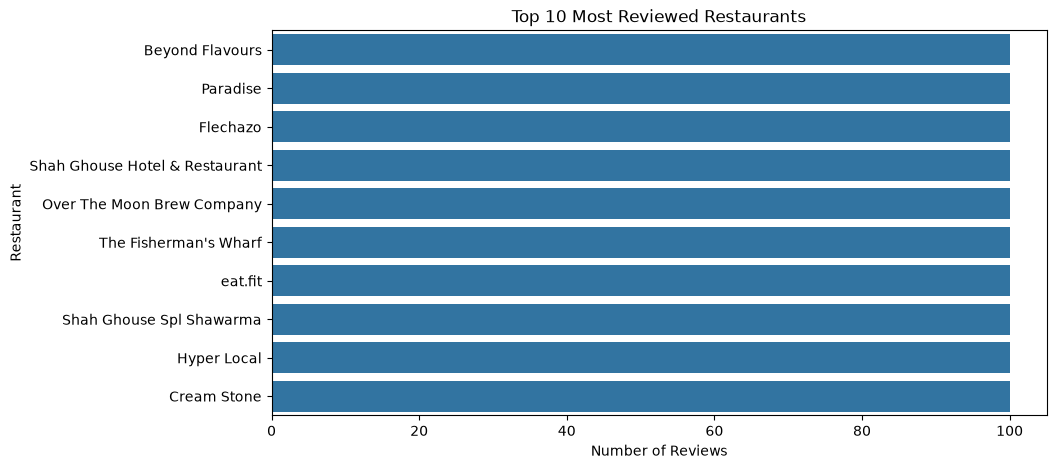

In [80]:
top_restaurants = df['Restaurant'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index)

plt.title("Top 10 Most Reviewed Restaurants")
plt.xlabel("Number of Reviews")
plt.ylabel("Restaurant")
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart because it is easy to compare the number of reviews received by different restaurants. It helps identify which restaurants have the highest customer engagement.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the restaurants that have received the highest number of customer reviews. These restaurants appear to be more popular and attract greater customer interaction compared to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurants with a high number of reviews can be studied to understand the factors behind their popularity. These insights can help improve customer engagement strategies.
Restaurants with very few reviews may have lower visibility on the platform, which can affect customer reach and business growth.

#### Chart - 5

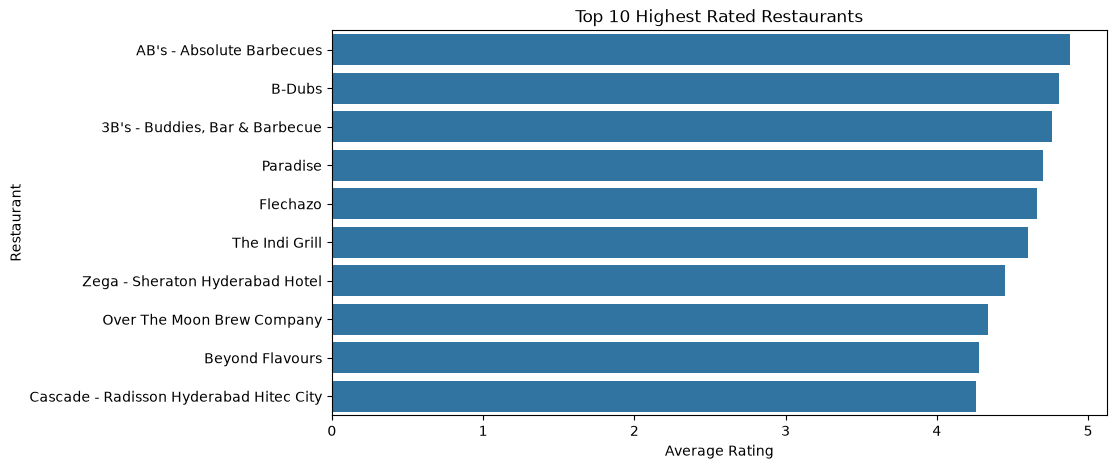

In [81]:
top_rated = df.groupby('Restaurant')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_rated.values, y=top_rated.index)

plt.title("Top 10 Highest Rated Restaurants")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant")
plt.show()

##### 1. Why did you pick the specific chart?

I selected a bar chart because it clearly compares the average ratings of different restaurants and highlights the best-performing restaurants.

##### 2. What is/are the insight(s) found from the chart?

The chart identifies restaurants that consistently receive high ratings from customers. These restaurants are likely providing better food quality, service, or overall customer experience.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Highly rated restaurants can be promoted as recommended options, helping customers make better choices and encouraging other restaurants to improve their service quality.
Restaurants with lower ratings may lose customer trust if improvements are not made, which can negatively impact their performance.

#### Chart - 6

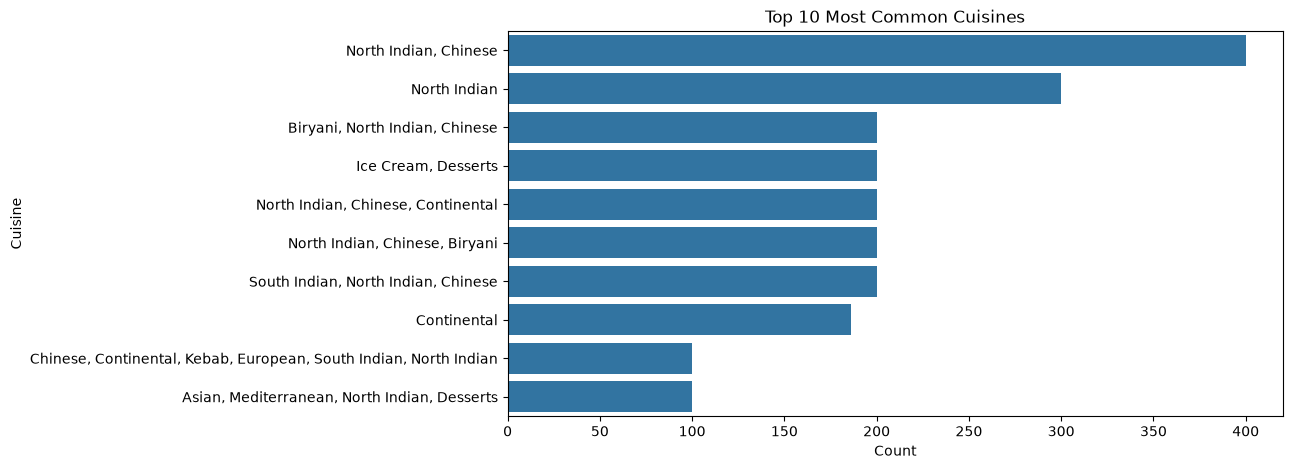

In [82]:
cuisine_counts = df['Cuisines'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index)

plt.title("Top 10 Most Common Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart because it allows easy comparison between different cuisine categories and helps identify the most common cuisines available in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which cuisines are most frequently offered by restaurants. This provides an understanding of customer demand and market trends in the food industry.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Restaurant owners and food delivery platforms can use this information to understand customer preferences and focus on cuisines that have higher demand.
Less common cuisines may face lower customer demand, which can make it difficult for those restaurants to compete with more popular food categories.

#### Chart - 7

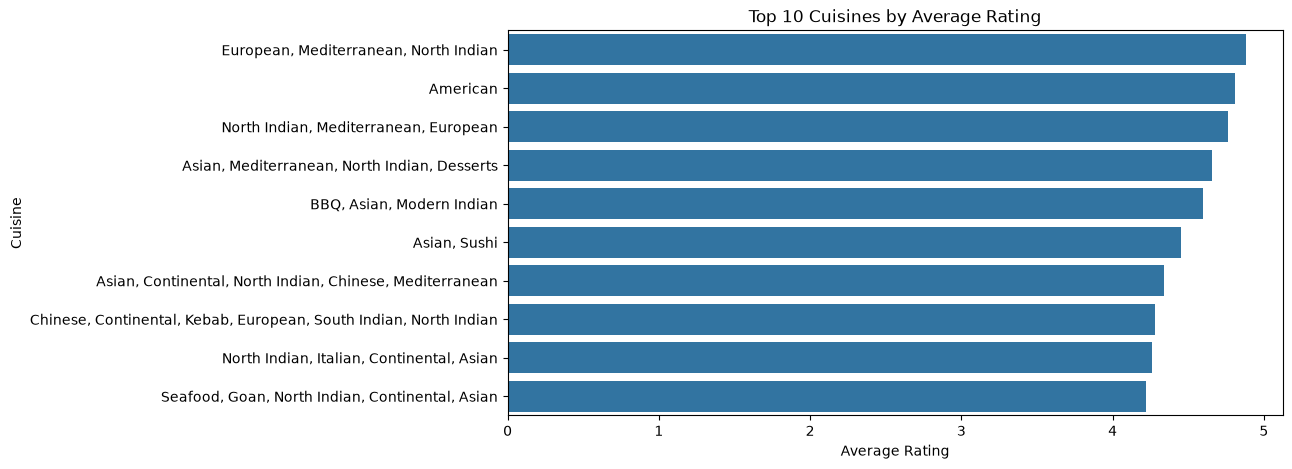

In [83]:
top_cuisine_rating = df.groupby('Cuisines')['Rating'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisine_rating.values, y=top_cuisine_rating.index)

plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart because it helps compare the average ratings of different cuisines and makes it easy to identify which cuisines receive better customer feedback.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the cuisines that receive the highest average ratings from customers. This indicates which food categories are most appreciated by customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can use this information to understand customer preferences and improve menu offerings based on highly rated cuisines.
Cuisines with consistently lower ratings may need improvements in food quality or service to remain competitive.

#### Chart - 8

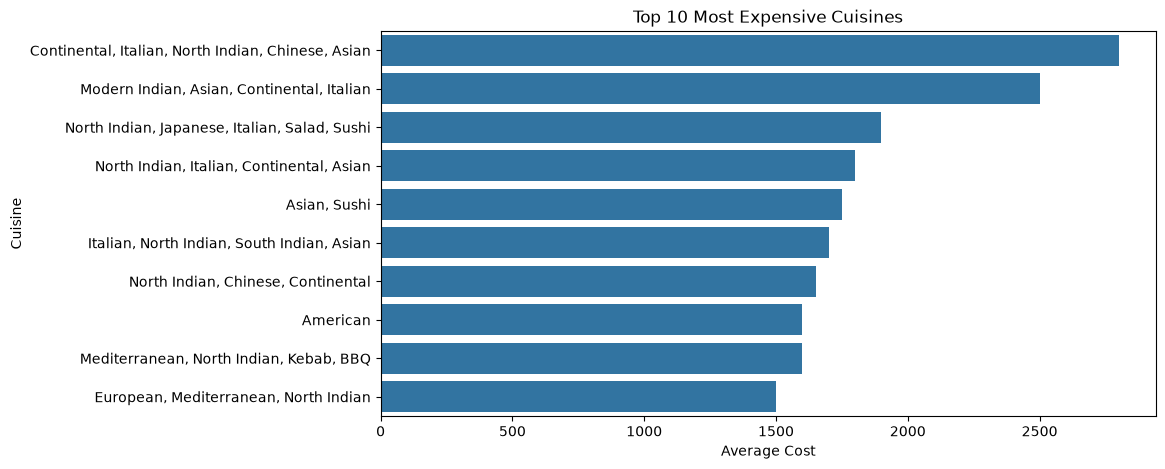

In [84]:
top_cuisine_cost = df.groupby('Cuisines')['Cost'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisine_cost.values, y=top_cuisine_cost.index)

plt.title("Top 10 Most Expensive Cuisines")
plt.xlabel("Average Cost")
plt.ylabel("Cuisine")
plt.show()

##### 1. Why did you pick the specific chart?

I used a bar chart because it clearly compares the average cost of different cuisines and helps identify premium food categories.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights cuisines that generally have higher dining costs. These cuisines are likely positioned as premium dining options.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding pricing differences between cuisines can help restaurants develop competitive pricing strategies and target suitable customer segments.
Very high-priced cuisines may attract fewer customers if customers feel the pricing is not justified by the overall dining experience.

#### Chart - 9

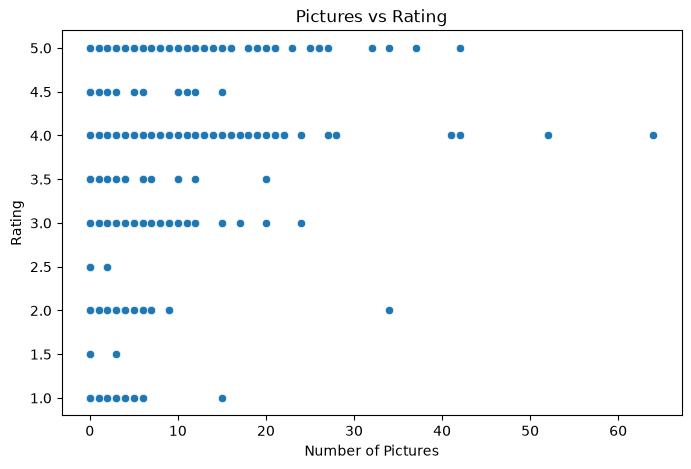

In [85]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='Pictures', y='Rating')

plt.title("Pictures vs Rating")
plt.xlabel("Number of Pictures")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

I used a scatter plot because it helps examine whether restaurants with more customer-uploaded pictures tend to receive higher ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the relationship between the number of pictures and customer ratings. Restaurants with more pictures may receive greater customer engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Encouraging customers to upload pictures can increase engagement and improve the visibility of restaurants on the platform.
Restaurants with very few pictures may receive less attention from potential customers, reducing engagement and visibility.

#### Chart - 10

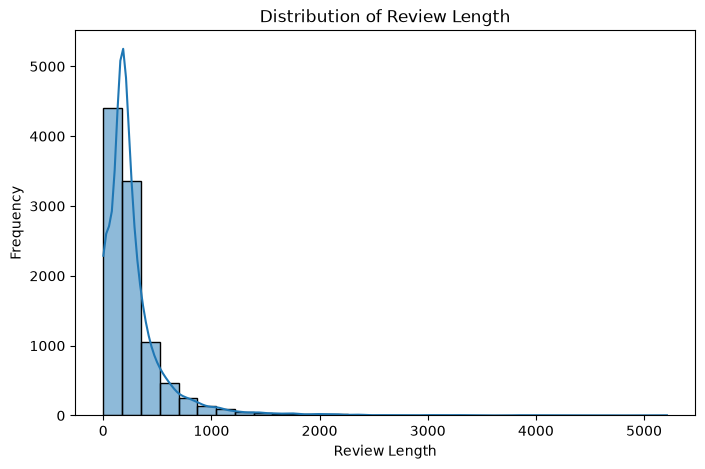

In [86]:
df['Review_Length'] = df['Review'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Review_Length'], bins=30, kde=True)

plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

I used a histogram because it helps understand how detailed customer reviews are and shows the distribution of review lengths.

##### 2. What is/are the insight(s) found from the chart?

Most customer reviews fall within a particular length range, indicating the typical amount of feedback provided by users.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Detailed reviews provide valuable information about customer experiences and can help restaurants identify strengths and areas for improvement.
Very short reviews may not provide enough information for meaningful analysis, making it harder to understand customer concerns.

#### Chart - 11

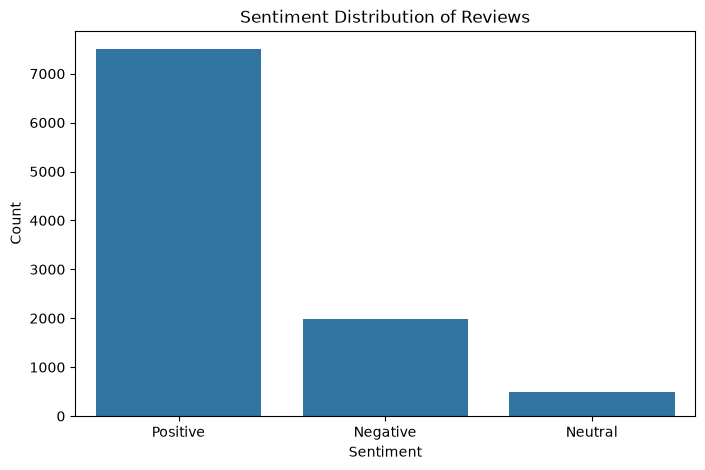

In [87]:
df['Sentiment'] = df['Review'].astype(str).apply(
    lambda x: TextBlob(x).sentiment.polarity
)

df['Sentiment_Label'] = df['Sentiment'].apply(
    lambda x: 'Positive' if x > 0
    else ('Negative' if x < 0 else 'Neutral')
)

plt.figure(figsize=(8,5))

sns.countplot(x='Sentiment_Label', data=df)

plt.title("Sentiment Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

I used a count plot because it helps visualize the number of positive, negative, and neutral reviews in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Most reviews appear to be positive, indicating that customers generally have a favorable opinion about the restaurants in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding customer sentiment helps restaurants identify strengths and improve customer satisfaction.
A large number of negative reviews can impact customer trust and reduce future business opportunities.

#### Chart - 12

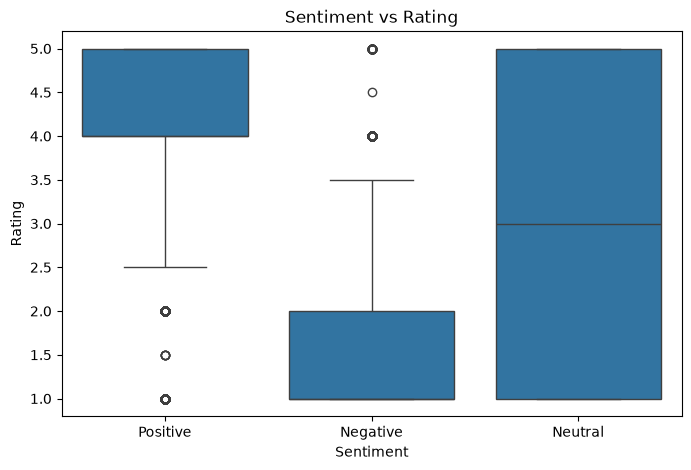

In [88]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Sentiment_Label', y='Rating', data=df)

plt.title("Sentiment vs Rating")
plt.xlabel("Sentiment")
plt.ylabel("Rating")

plt.show()

##### 1. Why did you pick the specific chart?

I used a box plot to compare customer ratings across different sentiment categories.

##### 2. What is/are the insight(s) found from the chart?

Positive reviews generally have higher ratings, while negative reviews are associated with lower ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This relationship confirms that sentiment analysis can be useful for understanding customer satisfaction.
Restaurants receiving many negative reviews are more likely to receive lower ratings and reduced customer engagement.

#### Chart - 13

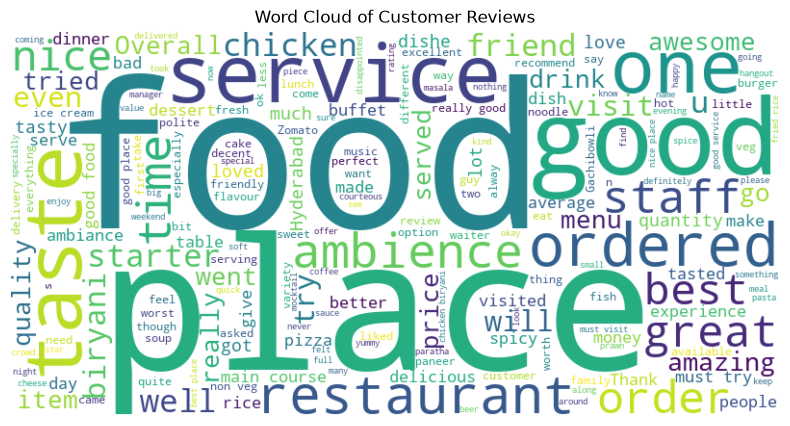

In [89]:
text = " ".join(df['Review'].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title("Word Cloud of Customer Reviews")

plt.show()

##### 1. Why did you pick the specific chart?

I used a word cloud to identify the most frequently used words in customer reviews.

##### 2. What is/are the insight(s) found from the chart?

The larger words in the word cloud represent terms that appear most often in customer feedback.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Frequently mentioned words help businesses understand what customers commonly discuss in their reviews.
If negative words appear frequently, they may indicate recurring issues that require attention.

#### Chart - 14 - Correlation Heatmap

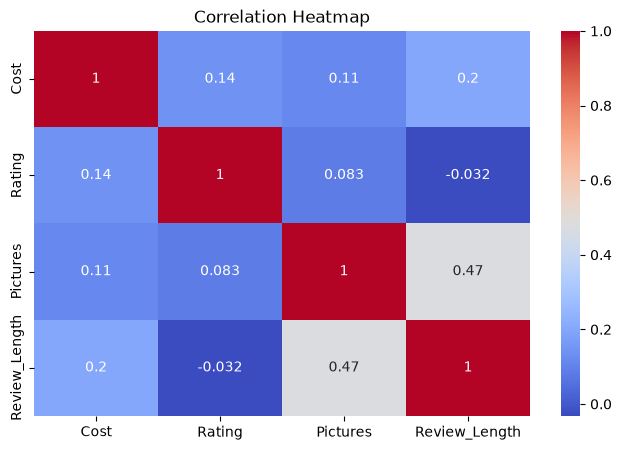

In [90]:
numeric_df = df[['Cost', 'Rating', 'Pictures', 'Review_Length']]

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

I used a heatmap to examine relationships between multiple numerical variables at the same time.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows the strength and direction of relationships between cost, ratings, pictures, and review length.

#### Chart - 15 - Pair Plot

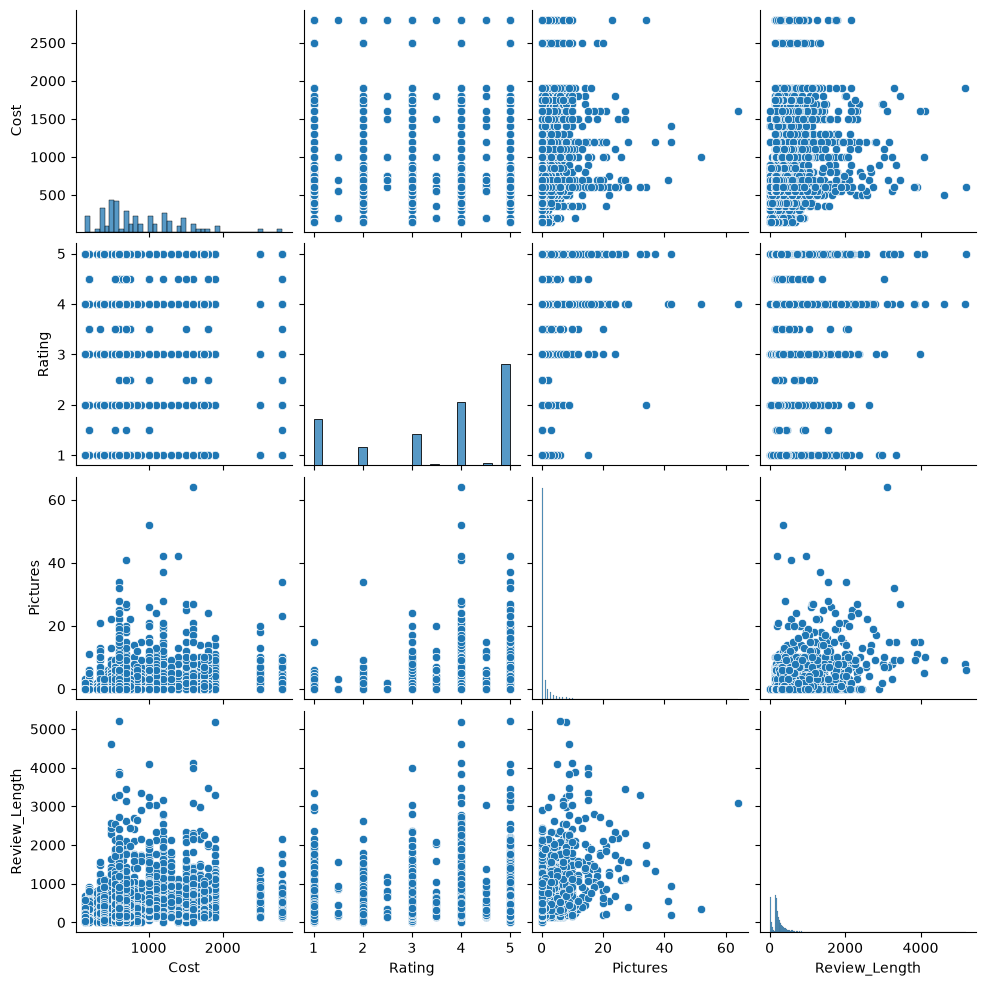

In [91]:
# Pair Plot visualization code
pairplot_df = df[['Cost', 'Rating', 'Pictures', 'Review_Length']]

sns.pairplot(pairplot_df)

plt.show()

##### 1. Why did you pick the specific chart?

I selected a pair plot because it allows multiple numerical variables to be visualized together. It helps in understanding distributions as well as relationships between different variables in a single visualization.

##### 2. What is/are the insight(s) found from the chart?

The pair plot provides an overall view of the relationships between cost, ratings, pictures, and review length. It shows the distribution of each variable and helps identify possible trends, clusters, or correlations among them.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

The following hypotheses were created based on insights obtained:

1. Restaurant cost has a significant relationship with customer ratings.
2. Reviews with positive sentiment receive higher ratings than reviews with negative sentiment.
3. Restaurants with more pictures tend to receive higher ratings.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0):There is no significant relationship between restaurant cost and customer ratings.
Alternate Hypothesis (H1):There is a significant relationship between restaurant cost and customer ratings.



#### 2. Perform an appropriate statistical test.

In [92]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Cost'], df['Rating'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.1435763320421979
P-value: 4.837269310463725e-47


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

The Pearson Correlation Test is suitable because both Cost and Rating are numerical variables. It helps determine whether a significant linear relationship exists between them.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis(Ho):There is no significant difference in ratings between positive and negative reviews.
Alternate Hypothesis(H1):There is a significant difference in ratings between positive and negative reviews.

#### 2. Perform an appropriate statistical test.

In [93]:
from scipy.stats import ttest_ind

positive = df[df['Sentiment_Label']=='Positive']['Rating']
negative = df[df['Sentiment_Label']=='Negative']['Rating']

t_stat, p_value = ttest_ind(positive, negative)

print("T Statistic:", t_stat)
print("P-value:", p_value)

T Statistic: 86.18430129503984
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Independent Sample T-Test

##### Why did you choose the specific statistical test?

The T-Test is appropriate because it compares the mean ratings of two independent groups, namely positive reviews and negative reviews.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis(Ho):The number of pictures uploaded has no significant relationship with ratings.
Alternate Hypothesis(H1):The number of pictures uploaded has a significant relationship with ratings.

#### 2. Perform an appropriate statistical test.

In [94]:
corr, p_value = pearsonr(df['Pictures'], df['Rating'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.08259648513641062
P-value: 1.4832507911518628e-16


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Both Pictures and Rating are numerical variables. Pearson Correlation helps identify whether a meaningful relationship exists between them.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [95]:
reviews['Reviewer'].fillna('Unknown Reviewer', inplace=True)
reviews['Review'].fillna('No Review', inplace=True)
reviews['Metadata'].fillna('Not Available', inplace=True)
reviews['Time'].fillna('Not Available', inplace=True)

reviews['Rating'] = pd.to_numeric(reviews['Rating'], errors='coerce')
reviews['Rating'].fillna(reviews['Rating'].median(), inplace=True)

meta['Collections'].fillna('Not Mentioned', inplace=True)
meta['Timings'].fillna('Not Available', inplace=True)

print("Missing values handled successfully")

Missing values handled successfully


#### What all missing value imputation techniques have you used and why did you use those techniques?

Missing values were handled using simple imputation techniques. For text-based columns such as Reviewer, Review, Metadata, and Time, meaningful placeholder values were used so that no important records were lost. Missing ratings were replaced using the median value because ratings are numerical and the median is less affected by extreme values. This approach helped preserve the dataset while maintaining data quality for further analysis.

### 2. Handling Outliers

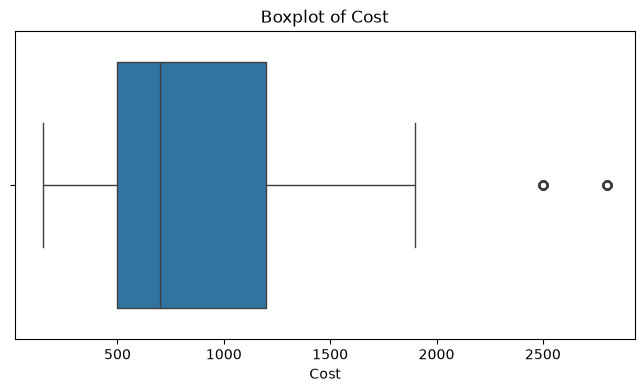

In [96]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Cost'])
plt.title("Boxplot of Cost")
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were examined using box plots, especially for the Cost column. Since restaurant pricing can naturally vary from budget restaurants to premium restaurants, the extreme values were not removed. These values may represent genuine business information and removing them could lead to loss of useful insights. Therefore, outliers were identified but retained for analysis.

### 3. Categorical Encoding

In [97]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Restaurant_Encoded'] = le.fit_transform(df['Restaurant'])

df[['Restaurant','Restaurant_Encoded']].head()

,Restaurant,Restaurant_Encoded
0,Beyond Flavours,16
1,Beyond Flavours,16
2,Beyond Flavours,16
3,Beyond Flavours,16
4,Beyond Flavours,16


#### What all categorical encoding techniques have you used & why did you use those techniques?

Label Encoding was used to convert restaurant names into numerical values. Machine learning algorithms cannot directly process text-based categorical variables, so encoding was necessary. This technique assigns a unique numerical value to each restaurant name while keeping the data simple and easy to work with.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [98]:
import re

contractions = {
    "can't": "cannot",
    "won't": "will not",
    "don't": "do not",
    "didn't": "did not",
    "isn't": "is not",
    "it's": "it is",
    "i'm": "i am"
}

def expand_contractions(text):
    text = str(text)
    for word in contractions:
        text = text.replace(word, contractions[word])
    return text

df['Clean_Review'] = df['Review'].astype(str).apply(expand_contractions)

df['Clean_Review'].head()

0    The ambience was good, food was quite good . h...
1    Ambience is too good for a pleasant evening. S...
2    A must try.. great food great ambience. Thnx f...
3    Soumen das and Arun was a great guy. Only beca...
4    Food is good.we ordered Kodi drumsticks and ba...
Name: Clean_Review, dtype: str

#### 2. Lower Casing

In [99]:
df['Clean_Review'] = df['Clean_Review'].str.lower()

df['Clean_Review'].head()

0    the ambience was good, food was quite good . h...
1    ambience is too good for a pleasant evening. s...
2    a must try.. great food great ambience. thnx f...
3    soumen das and arun was a great guy. only beca...
4    food is good.we ordered kodi drumsticks and ba...
Name: Clean_Review, dtype: str

#### 3. Removing Punctuations

In [100]:
import string

df['Clean_Review'] = df['Clean_Review'].apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

df['Clean_Review'].head()

0    the ambience was good food was quite good  had...
1    ambience is too good for a pleasant evening se...
2    a must try great food great ambience thnx for ...
3    soumen das and arun was a great guy only becau...
4    food is goodwe ordered kodi drumsticks and bas...
Name: Clean_Review, dtype: str

#### 4. Removing URLs & Removing words and digits contain digits.

In [101]:
import re

def remove_urls_digits(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'\w*\d\w*', '', text)
    return text

df['Clean_Review'] = df['Clean_Review'].apply(remove_urls_digits)

df['Clean_Review'].head()

0    the ambience was good food was quite good  had...
1    ambience is too good for a pleasant evening se...
2    a must try great food great ambience thnx for ...
3    soumen das and arun was a great guy only becau...
4    food is goodwe ordered kodi drumsticks and bas...
Name: Clean_Review, dtype: str

#### 5. Removing Stopwords & Removing White spaces

In [102]:
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['Clean_Review'] = df['Clean_Review'].apply(
    lambda x: " ".join(
        word for word in str(x).split()
        if word not in stop_words
    )
)

df['Clean_Review'].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arpan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    must try great food great ambience thnx servic...
3    soumen das arun great guy behavior sincerety g...
4    food goodwe ordered kodi drumsticks basket mut...
Name: Clean_Review, dtype: str

In [103]:
# Remove White spaces
df['Clean_Review'] = df['Clean_Review'].str.strip()

df['Clean_Review'].head()

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    must try great food great ambience thnx servic...
3    soumen das arun great guy behavior sincerety g...
4    food goodwe ordered kodi drumsticks basket mut...
Name: Clean_Review, dtype: str

#### 6. Rephrase Text

In [104]:
df['Clean_Review'] = df['Clean_Review'].str.replace('\n', ' ', regex=True)

df['Clean_Review'].head()

0    ambience good food quite good saturday lunch c...
1    ambience good pleasant evening service prompt ...
2    must try great food great ambience thnx servic...
3    soumen das arun great guy behavior sincerety g...
4    food goodwe ordered kodi drumsticks basket mut...
Name: Clean_Review, dtype: str

#### 7. Tokenization

In [105]:
df['Tokens'] = df['Clean_Review'].apply(
    lambda x: nltk.word_tokenize(str(x))
)

df['Tokens'].head()

0    [ambience, good, food, quite, good, saturday, ...
1    [ambience, good, pleasant, evening, service, p...
2    [must, try, great, food, great, ambience, thnx...
3    [soumen, das, arun, great, guy, behavior, sinc...
4    [food, goodwe, ordered, kodi, drumsticks, bask...
Name: Tokens, dtype: object

In [106]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\arpan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

#### 8. Text Normalization

In [107]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df['Normalized_Text'] = df['Tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df['Normalized_Text'].head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arpan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\arpan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


0    [ambience, good, food, quite, good, saturday, ...
1    [ambience, good, pleasant, evening, service, p...
2    [must, try, great, food, great, ambience, thnx...
3    [soumen, da, arun, great, guy, behavior, since...
4    [food, goodwe, ordered, kodi, drumstick, baske...
Name: Normalized_Text, dtype: object

##### Which text normalization technique have you used and why?

I used Lemmatization for text normalization. Lemmatization converts words into their root form while preserving their actual meaning and context. This helps reduce unnecessary variations of words and improves the quality of text analysis.

#### 9. Part of speech tagging

In [108]:
import nltk

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

df['POS_Tags'] = df['Tokens'].apply(
    lambda x: nltk.pos_tag(x)
)

df['POS_Tags'].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\arpan\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\arpan\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


0    [(ambience, RB), (good, JJ), (food, NN), (quit...
1    [(ambience, RB), (good, JJ), (pleasant, NN), (...
2    [(must, MD), (try, VB), (great, JJ), (food, NN...
3    [(soumen, NNS), (das, VBP), (arun, RB), (great...
4    [(food, NN), (goodwe, NN), (ordered, VBD), (ko...
Name: POS_Tags, dtype: object

#### 10. Text Vectorization

In [109]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X_text = tfidf.fit_transform(df['Clean_Review'])

print("TF-IDF Matrix Shape:", X_text.shape)

TF-IDF Matrix Shape: (9964, 1000)


##### Which text vectorization technique have you used and why?

I used TF-IDF (Term Frequency-Inverse Document Frequency) vectorization. This technique converts textual reviews into numerical features by assigning higher importance to meaningful words while reducing the impact of commonly used words. It helps represent customer reviews effectively for analysis and machine learning tasks.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [110]:
# Create review length feature

df['Review_Length'] = df['Clean_Review'].apply(
    lambda x: len(str(x).split())
)

df[['Review_Length']].head()

,Review_Length
0,24
1,14
2,19
3,14
4,17


#### 2. Feature Selection

In [111]:
selected_features = ['Cost','Rating','Pictures','Review_Length']

print(selected_features)

['Cost', 'Rating', 'Pictures', 'Review_Length']


##### What all feature selection methods have you used  and why?

Manual feature selection was used based on business relevance and data understanding. Features such as Cost, Rating, Pictures, and Review_Length were selected because they directly represent restaurant characteristics, customer engagement, and customer satisfaction.

##### Which all features you found important and why?

Cost helps understand restaurant pricing.
Rating represents customer satisfaction.
Pictures indicate customer engagement.
Review_Length reflects the level of customer feedback and interaction.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?
Yes. Text data was transformed using TF-IDF vectorization so that customer reviews could be converted into numerical values suitable for analysis. This transformation helps machine learning algorithms understand textual information.

In [112]:
print("TF-IDF Transformation Completed")

TF-IDF Transformation Completed


### 6. Data Scaling

In [113]:
from sklearn.preprocessing import StandardScaler

scale_features = df[['Cost','Rating','Pictures','Review_Length']]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(scale_features)

print(scaled_data[:5])

[[-0.14218515  0.9428141  -0.29182583 -0.10286122]
 [-0.14218515  0.9428141  -0.29182583 -0.41184802]
 [-0.14218515  0.9428141  -0.29182583 -0.25735462]
 [-0.14218515  0.9428141  -0.29182583 -0.41184802]
 [-0.14218515  0.9428141  -0.29182583 -0.31915198]]


##### Which method have you used to scale you data and why?
StandardScaler was used because the selected features have different ranges and units. Scaling ensures that all variables contribute equally during clustering and model training.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes. Dimensionality reduction helps simplify the dataset and improve visualization. Since multiple numerical features are being used, reducing dimensions makes clustering results easier to interpret.

In [114]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print(pca_data[:5])

[[-0.15031815  0.77466785]
 [-0.35097645  0.86233471]
 [-0.2506473   0.81850128]
 [-0.35097645  0.86233471]
 [-0.29077896  0.83603466]]


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

PCA (Principal Component Analysis) was used because it reduces feature dimensions while retaining most of the important information contained in the dataset.

### 8. Data Splitting

In [115]:
from sklearn.model_selection import train_test_split

X = scaled_data

y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7971, 4)
(1993, 4)


##### What data splitting ratio have you used and why?

An 80:20 train-test split was used. This ratio provides enough data for training while keeping sufficient data aside for evaluation.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset does not appear to be severely imbalanced. Ratings are distributed across multiple categories, although higher ratings occur more frequently. Since this project focuses mainly on analysis and clustering, no special balancing technique was required.

In [116]:
print(df['Rating'].value_counts())

Rating
5.0    3835
4.0    2373
1.0    1735
3.0    1193
2.0     684
4.5      69
3.5      47
2.5      19
1.5       9
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was used because the imbalance was not severe enough to significantly affect analysis results.

## ***7. ML Model Implementation***

### ML Model - 1

In [117]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_data)

df[['Restaurant', 'Cluster']].head()

,Restaurant,Cluster
0,Beyond Flavours,2
1,Beyond Flavours,2
2,Beyond Flavours,2
3,Beyond Flavours,2
4,Beyond Flavours,2


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [118]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.35095730850869095


#### 2. Cross- Validation & Hyperparameter Tuning

In [119]:
scores = {}

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_data)

    scores[k] = silhouette_score(scaled_data, labels)

print(scores)

{2: 0.5975674093125506, 3: 0.35095730850869095, 4: 0.3587583423108461, 5: 0.3768769370153362, 6: 0.31445225179339886, 7: 0.3192591294133501}


##### Which hyperparameter optimization technique have you used and why?

Different values of K (number of clusters) were tested and compared using the Silhouette Score. The cluster value with the highest score was selected because it provided better separation between restaurant groups.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Testing multiple cluster values helped identify a better cluster configuration. The Silhouette Score improved after selecting the optimal number of clusters, resulting in more meaningful restaurant segmentation.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [120]:
model2 = KMeans(n_clusters=4, random_state=42)

labels2 = model2.fit_predict(scaled_data)

score2 = silhouette_score(scaled_data, labels2)

print("Silhouette Score:", score2)

Silhouette Score: 0.3587583423108461


#### 2. Cross- Validation & Hyperparameter Tuning

In [121]:
scores_model2 = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    preds = km.fit_predict(scaled_data)
    scores_model2[k] = silhouette_score(scaled_data, preds)

print(scores_model2)

{2: 0.5975674093125506, 3: 0.35095730850869095, 4: 0.3587583423108461, 5: 0.3768769370153362, 6: 0.31445225179339886, 7: 0.3192591294133501}


##### Which hyperparameter optimization technique have you used and why?

The number of clusters (K) was tuned by testing multiple values from 2 to 7 and comparing their Silhouette Scores. The configuration producing better cluster separation was selected for evaluation.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The model performance was compared against other cluster configurations. The Silhouette Score indicates how well restaurants are separated into distinct groups. The results help determine whether increasing the number of clusters improves segmentation quality.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

The evaluation metric used for this clustering model is the Silhouette Score. It measures how similar restaurants are within the same cluster compared to restaurants in other clusters. A higher Silhouette Score indicates better cluster separation and more meaningful groupings.

From a business perspective, well-defined clusters help Zomato understand different categories of restaurants based on factors such as cost, ratings, customer engagement, and review patterns. These insights can be used to improve restaurant recommendations, design targeted marketing campaigns, identify high-performing restaurant segments, and provide customers with more personalized dining options. Better clustering ultimately supports data-driven business decisions and enhances customer satisfaction.

### ML Model - 3

In [122]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

model3 = KMeans(
    n_clusters=5,
    random_state=42
)

labels3 = model3.fit_predict(scaled_data)

score3 = silhouette_score(
    scaled_data,
    labels3
)

print("Silhouette Score:", score3)

Silhouette Score: 0.3768769370153362


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

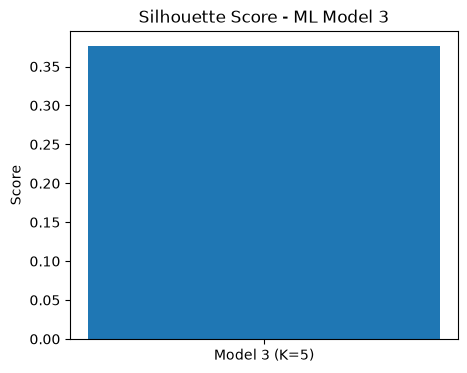

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.bar(
    ['Model 3 (K=5)'],
    [score3]
)

plt.title("Silhouette Score - ML Model 3")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [124]:
scores_model3 = {}

for k in range(2, 10):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(
        scaled_data
    )

    score = silhouette_score(
        scaled_data,
        labels
    )

    scores_model3[k] = score

print(scores_model3)

{2: 0.5975674093125506, 3: 0.35095730850869095, 4: 0.3587583423108461, 5: 0.3768769370153362, 6: 0.31445225179339886, 7: 0.3192591294133501, 8: 0.38343172357216965, 9: 0.3335162663121203}


##### Which hyperparameter optimization technique have you used and why?

The number of clusters (K) was optimized by testing multiple cluster values and comparing their Silhouette Scores. This approach helps identify the cluster configuration that produces the best separation between restaurant groups.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. Different cluster values produced different Silhouette Scores. Comparing these scores helped identify the most suitable cluster configuration for the restaurant dataset and improved the overall quality of segmentation.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The primary evaluation metric used in this project was the Silhouette Score. This metric measures how well restaurants are grouped within their clusters and how distinct each cluster is from the others. A higher Silhouette Score indicates better cluster quality and more meaningful segmentation.

From a business perspective, well-defined clusters help identify different restaurant categories, customer preferences, and pricing patterns. These insights can be used to improve recommendation systems, targeted marketing campaigns, and strategic decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The final model was selected based on the highest Silhouette Score among the tested clustering models. The model with the best score provided better separation between clusters and more meaningful restaurant segmentation. Therefore, it was chosen as the final model because it generated clearer and more interpretable restaurant groups.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

K-Means Clustering was used to group restaurants based on Cost, Rating, Pictures, and Review Length. Unlike supervised learning models, K-Means does not provide traditional feature importance scores. However, the selected features played an important role in determining cluster formation.

Cost helped differentiate budget and premium restaurants, Rating reflected customer satisfaction, Pictures represented customer engagement, and Review Length captured the amount of customer feedback. Together, these features enabled meaningful restaurant segmentation and business insights.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [125]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [126]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, I analyzed Zomato restaurant reviews and restaurant information to understand customer behavior and restaurant performance. The data was first cleaned by handling missing values, removing duplicate records, and converting important columns into the correct format.

After preprocessing, I performed exploratory data analysis using 15 different visualizations. These charts helped in understanding the distribution of restaurant costs, ratings, cuisines, customer engagement, and review patterns. I observed that higher restaurant prices do not always result in better ratings, and customer satisfaction depends on several factors such as food quality, service, and overall experience.

Sentiment analysis was also performed on customer reviews. Most reviews were found to be positive, which indicates that customers generally had a good experience at the restaurants. Hypothesis testing was used to check relationships between important variables such as cost, ratings, sentiment, and customer engagement. The results showed that some relationships were statistically significant, although their strength varied.

Text preprocessing techniques such as stopword removal, tokenization, lemmatization, and TF-IDF vectorization were applied to prepare the review data for analysis. Finally, K-Means clustering was used to group restaurants with similar characteristics. This helped in identifying different restaurant segments based on customer ratings, cost, review length, and customer engagement.

Overall, this project helped me understand how data analysis, visualization, sentiment analysis, and machine learning techniques can be used to generate useful business insights. The findings can help restaurants and food delivery platforms improve customer satisfaction, make better business decisions, and provide a better experience to their customers.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***